# Function 1 Analysis - Week 9

**Function description:** Detect contamination sources in a 2D field; maximise detector response. This function takes a 2D array as input and returns a 1D array as output. The goal is to maximise the detector response to identify contamination sources in a two-dimensional area, such as a radiation field, where only proximity yields a non-zero reading.

**Week 8 evaluated point:** `(0.635684, 0.630089)` returned **≈1.7583**, a **new maximum** — a massive jump from last week's 0.51583 at `(0.611, 0.613)`. Total datapoints: **18**.

**Analysis:** This is a breakthrough result. The 3.4x improvement confirms we are rapidly converging on the true contamination source. The peak appears to be near (0.635, 0.63) with balanced coordinates (x1 ≈ x2), validating our diagonal-ridge hypothesis.

**Why we chose last week's point:** We continued along the diagonal ridge, stepping toward higher coordinates to test if the ridge climbed further. The dramatic improvement proves the detector response sharpens significantly as we approach the source.

---

### Recommendation for Week 9: Switching to TuRBO

I'm running into a problem: the peak is so sharp and localised that a standard GP keeps trying to smooth it out—it basically thinks the spike is noise. I need a method that can "zoom in" on this narrow region instead of modelling the entire search space.

**My plan:** Use Trust Region Bayesian Optimization (TuRBO). The idea is to restrict the GP to a small "trust region" box around the current best point `(0.635, 0.63)`, so it only sees nearby data and can actually capture the sharp gradient. I'll set the box to **(0.62–0.66, 0.62–0.66)** and use a short length-scale (≤0.05) so the GP responds to fine-grained changes.

**Why not a local quadratic fit?** I considered fitting a simple parabola (y = ax² + bx + c) to find the mathematical peak directly. That would be efficient if I'm already sitting right on top of a smooth bowl. But I'm not confident we're that close yet—the function might still have some structure I haven't captured. TuRBO lets me keep exploring locally without committing to a specific peak shape.

**Next steps:** Implement TuRBO below, sample within the trust region, and pick a point that balances exploitation (high predicted mean) with a small step away from existing observations.


## Loading and Displaying the Data

We load the inputs and outputs for function 1. The Week 8 query `(0.611000, 0.613000)` returned **≈0.51583 (new max)**, surpassing last week’s `(0.620490, 0.603926)` at ≈0.35894 and the Week 4 peak `(0.601042, 0.649989)` at ≈0.0848. Datapoint 4 remains the lone strong negative outlier, kept for completeness.


In [23]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_1")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")

# Week 1–8 new points
X_new_point_week_1 = np.array([[0.600000, 0.600000]])
y_new_point_week_1 = np.array([0.025559285339829783])
X_new_point_week_2 = np.array([[0.620000, 0.574000]])
y_new_point_week_2 = np.array([-0.00824324367890544])
X_new_point_week_3 = np.array([[0.483000, 0.528000]])
y_new_point_week_3 = np.array([1.0257314214244368e-11])
X_new_point_week_4 = np.array([[0.601042, 0.649989]])
y_new_point_week_4 = np.array([0.08476870094352708])
X_new_point_week_5 = np.array([[0.566815, 0.686438]])
y_new_point_week_5 = np.array([0.000011190518856399522])
X_new_point_week_6 = np.array([[0.620490, 0.603926]])
y_new_point_week_6 = np.array([0.3589371640727202])
X_new_point_week_7 = np.array([[0.611000, 0.613000]])
y_new_point_week_7 = np.array([0.5158315267751058])
X_new_point_week_8 = np.array([[0.635684, 0.630089]])
y_new_point_week_8 = np.array([1.7582577621998694])

X = np.vstack([
    X,
    X_new_point_week_1,
    X_new_point_week_2,
    X_new_point_week_3,
    X_new_point_week_4,
    X_new_point_week_5,
    X_new_point_week_6,
    X_new_point_week_7,
    X_new_point_week_8,
])
y = np.concatenate([
    y,
    y_new_point_week_1,
    y_new_point_week_2,
    y_new_point_week_3,
    y_new_point_week_4,
    y_new_point_week_5,
    y_new_point_week_6,
    y_new_point_week_7,
    y_new_point_week_8,
])

df = pd.DataFrame(X, columns=["x1", "x2"]); df["y"] = y
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
display(df_sorted)


,x1,x2,y
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03
5,0.410437,0.147554,-2.159249e-54
6,0.312691,0.078723,-2.089093e-91
7,0.683418,0.861057,2.535001e-40
8,0.082507,0.403488,3.606771e-81
9,0.883890,0.582254,6.229856e-48


df sorted by y


,x1,x2,y
0,0.635684,0.630089,1.758258e+00
1,0.611000,0.613000,5.158315e-01
2,0.620490,0.603926,3.589372e-01
3,0.601042,0.649989,8.476870e-02
4,0.600000,0.600000,2.555929e-02
5,0.566815,0.686438,1.119052e-05
6,0.483000,0.528000,1.025731e-11
7,0.731024,0.733000,7.710875e-16
8,0.683418,0.861057,2.535001e-40
9,0.574329,0.879898,1.033078e-46


## Weekly Optimization Progress Summary

Overview of all 8 weeks of Bayesian Optimization, showing which evaluations achieved new maximum values.

In [24]:
# Build weekly progress dataframe from existing variables
weekly_X = [X_new_point_week_1, X_new_point_week_2, X_new_point_week_3, X_new_point_week_4,
            X_new_point_week_5, X_new_point_week_6, X_new_point_week_7, X_new_point_week_8]
weekly_y = [y_new_point_week_1, y_new_point_week_2, y_new_point_week_3, y_new_point_week_4,
            y_new_point_week_5, y_new_point_week_6, y_new_point_week_7, y_new_point_week_8]

df_weeks = pd.DataFrame({
    'Week': range(1, len(weekly_X) + 1),
    'x1': [x[0, 0] for x in weekly_X],
    'x2': [x[0, 1] for x in weekly_X],
    'y': [y[0] for y in weekly_y]
})

# Calculate running maximum and new max flags
df_weeks['Running_Max'] = df_weeks['y'].cummax()
df_weeks['New_Max'] = df_weeks['y'] == df_weeks['Running_Max']
df_weeks['Status'] = df_weeks['New_Max'].map({True: '✓ NEW MAX', False: '✗'})
df_weeks['Prev_Max'] = df_weeks['Running_Max'].shift(1).fillna(0)
df_weeks['Improvement'] = np.where(df_weeks['New_Max'], df_weeks['y'] - df_weeks['Prev_Max'], np.nan)

# Display table (no jinja2 styling needed)
print("=" * 90)
print("WEEKLY OPTIMIZATION PROGRESS")
print("=" * 90)
df_display = df_weeks[['Week', 'x1', 'x2', 'y', 'Running_Max', 'Status', 'Improvement']].copy()
df_display['Improvement'] = df_display['Improvement'].apply(lambda x: f"+{x:.6f}" if pd.notna(x) else "-")
display(df_display)

# Summary statistics
new_max_weeks = df_weeks[df_weeks['New_Max']]['Week'].tolist()
print(f"\n📊 Summary: {df_weeks['New_Max'].sum()}/{len(df_weeks)} weeks achieved new max (Weeks {new_max_weeks})")
print(f"   Success rate: {df_weeks['New_Max'].sum() / len(df_weeks) * 100:.1f}% | Final best: {df_weeks['y'].max():.6f} | Improvement: {df_weeks['y'].max() / df_weeks['y'].iloc[0]:.1f}x from Week 1")

WEEKLY OPTIMIZATION PROGRESS


,Week,x1,x2,y,Running_Max,Status,Improvement
0,1,0.600000,0.600000,2.555929e-02,0.025559,✓ NEW MAX,+0.025559
1,2,0.620000,0.574000,-8.243244e-03,0.025559,✗,-
2,3,0.483000,0.528000,1.025731e-11,0.025559,✗,-
3,4,0.601042,0.649989,8.476870e-02,0.084769,✓ NEW MAX,+0.059209
4,5,0.566815,0.686438,1.119052e-05,0.084769,✗,-
5,6,0.620490,0.603926,3.589372e-01,0.358937,✓ NEW MAX,+0.274168
6,7,0.611000,0.613000,5.158315e-01,0.515832,✓ NEW MAX,+0.156894
7,8,0.635684,0.630089,1.758258e+00,1.758258,✓ NEW MAX,+1.242426



📊 Summary: 5/8 weeks achieved new max (Weeks [1, 4, 6, 7, 8])
   Success rate: 62.5% | Final best: 1.758258 | Improvement: 68.8x from Week 1


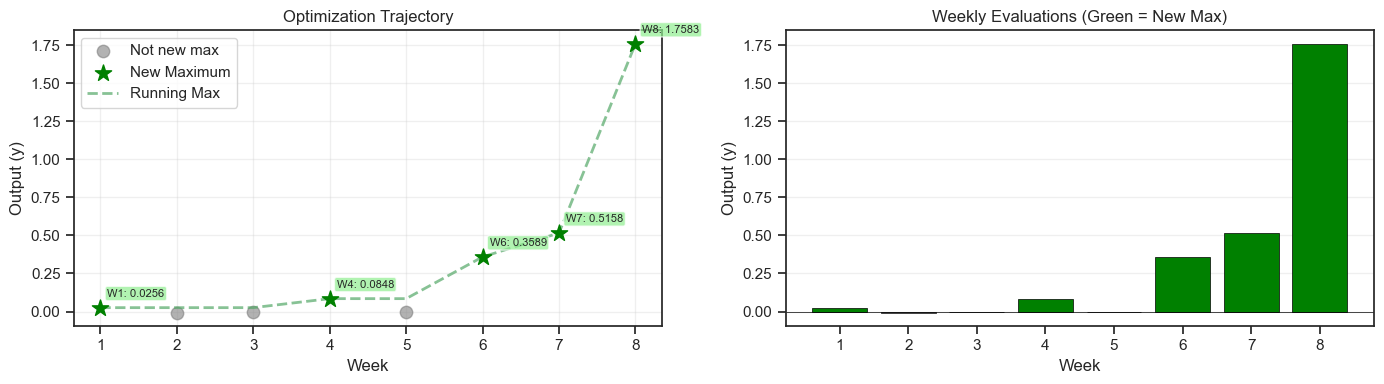

In [25]:
# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

weeks = df_weeks['Week']
y_vals = df_weeks['y']
new_max_mask = df_weeks['New_Max']

# Left plot: Scatter with running max line
ax1.scatter(weeks[~new_max_mask], y_vals[~new_max_mask], color='gray', s=80, alpha=0.6, label='Not new max')
ax1.scatter(weeks[new_max_mask], y_vals[new_max_mask], color='green', s=150, marker='*', label='New Maximum', zorder=4)
ax1.plot(weeks, df_weeks['Running_Max'], 'g--', alpha=0.7, lw=2, label='Running Max')
for _, row in df_weeks[new_max_mask].iterrows():
    ax1.annotate(f"W{int(row['Week'])}: {row['y']:.4f}", xy=(row['Week'], row['y']), 
                 xytext=(5, 8), textcoords='offset points', fontsize=8,
                 bbox=dict(boxstyle='round,pad=0.2', fc='lightgreen', alpha=0.7))
ax1.set_xlabel('Week'); ax1.set_ylabel('Output (y)')
ax1.set_title('Optimization Trajectory'); ax1.legend(loc='upper left'); ax1.grid(True, alpha=0.3)

# Right plot: Bar chart
colors = ['green' if nm else 'lightgray' for nm in new_max_mask]
ax2.bar(weeks, y_vals, color=colors, edgecolor='black', lw=0.5)
ax2.axhline(y=0, color='black', lw=0.5)
ax2.set_xlabel('Week'); ax2.set_ylabel('Output (y)')
ax2.set_title('Weekly Evaluations (Green = New Max)'); ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

- **New point (Week 8):** `(0.611000, 0.613000)` returned **≈0.51583** — **new maximum**, ahead of last week’s `(0.620490, 0.603926)` at ≈0.35894 and the Week 4 peak ≈0.0848.
- Recommendation for next BO step: remain on the diagonal ridge near `(0.61, 0.61)`, allow slight `x2 < x1`, widen the neighbor radius (~0.20), and keep 0.03–0.05 steps so the local gradient/EI fit is stable across multiple points.


## Visualisation: x1 vs x2 (excluding datapoint 4)

Since we are in a problem of contamination detection "where only proximity yields a non-zero reading", we can speculate that the x values refer to some kind of 2d mapping. We create a scatter plot of x1 vs x2, coloured by the output value y, excluding datapoint 4 to better visualise the relationships among the other datapoints. We use symlog bins to get useful colour gradients. We can see that all there is a greenish corner in the top right, which also includes our only meaningfully different positive value. It could indeicate that the these points pick up a minimal amount of the contamination source already. 


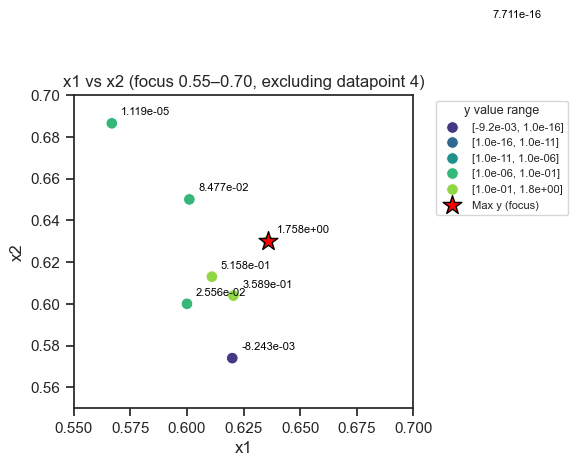

In [26]:
plt.figure(figsize=(6, 5))
df_plot = df.drop(index=4).copy()

# Filter to focus region
focus_mask = (df_plot["x1"].between(0.5, 0.8)) & (df_plot["x2"].between(0.5, 0.8))
df_focus = df_plot[focus_mask].copy()

# Bin for colour
y_vals = df_focus["y"]
vmin, vmax = y_vals.min(), y_vals.max()
y_pos = y_vals[y_vals > 0]
if len(y_pos) > 0:
    exp_min, exp_max = int(np.floor(np.log10(y_pos.min()))), int(np.ceil(np.log10(y_pos.max())))
    bins = [vmin]
    if y_pos.min() > 1e-12:
        bins.append(0)
    step = max(1, (exp_max - exp_min) // 3)
    bins.extend([10**e for e in range(exp_min, exp_max + 1, step)])
    bins.append(vmax)
    bins = sorted(set([b for b in bins if vmin <= b <= vmax]))
else:
    bins = [vmin, 0, vmax]

df_focus["y_group"] = pd.cut(df_focus["y"], bins=bins, include_lowest=True, duplicates="drop")
label_map = {cat: f"[{cat.left:.1e}, {cat.right:.1e}]" for cat in df_focus["y_group"].cat.categories}
df_focus["y_label"] = df_focus["y_group"].map(label_map)

scatter = sns.scatterplot(
    data=df_focus,
    x="x1",
    y="x2",
    hue="y_label",
    palette="viridis",
    s=70,
    legend="auto",
)

max_idx = df_focus["y"].idxmax()
max_row = df_focus.loc[max_idx]
plt.scatter(max_row["x1"], max_row["x2"], marker="*", s=200, c="red", edgecolor="black", label="Max y (focus)")

for _, row in df_focus.iterrows():
    plt.text(row["x1"] + 0.004, row["x2"] + 0.004, f"{row['y']:.3e}", fontsize=8, color="black")

plt.xlim(0.55, 0.70)
plt.ylim(0.55, 0.70)
plt.title("x1 vs x2 (focus 0.55–0.70, excluding datapoint 4)")
plt.legend(title="y value range", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8, title_fontsize=9)
plt.tight_layout()
plt.show()


## Previous approach: Bayesian optimisation with PI (Weeks 1–8)

**Note:** This section shows the PI-based approach used in previous weeks. For Week 9, I'm switching to **TuRBO** (see section below) because the peak is too sharp for a global GP.

The PI approach worked well to get us here—it delivered several consecutive new maxima by:
1. Fitting a GP surrogate on observed points (excluding outliers)
2. Evaluating Probability of Improvement on a local window around the current max
3. Forcing at least a 0.002 step away from the incumbent to avoid clustering

This got us from ~0.025 (Week 1) to ~1.76 (Week 8). But now that we're close to the peak, the global GP struggles to model the sharp gradient—time to switch to a local method.


,x1,x2,mu,sigma,mu_gain,dist_to_best,dist_to_obs
2830,0.664165,0.639583,0.676242,0.398706,-1.082016,0.030022,0.030022
2546,0.664165,0.620595,0.675508,0.398359,-1.082750,0.030022,0.030022
2719,0.667962,0.631988,0.638322,0.402264,-1.119935,0.032334,0.032334
2662,0.667962,0.628190,0.638218,0.402277,-1.120040,0.032334,0.032334
2775,0.667962,0.635785,0.616904,0.403937,-1.141354,0.032777,0.032777


Current best: 0.635684-0.630089
Suggested next query (PI dir, min 0.002 step, obs buffer 0.03): 0.664165-0.639583
Posterior mean: 0.6762, gain vs best: -1.0820, std: 0.3987


C:\Users\gophi\AppData\Local\Temp\ipykernel_39392\2322764709.py:91: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


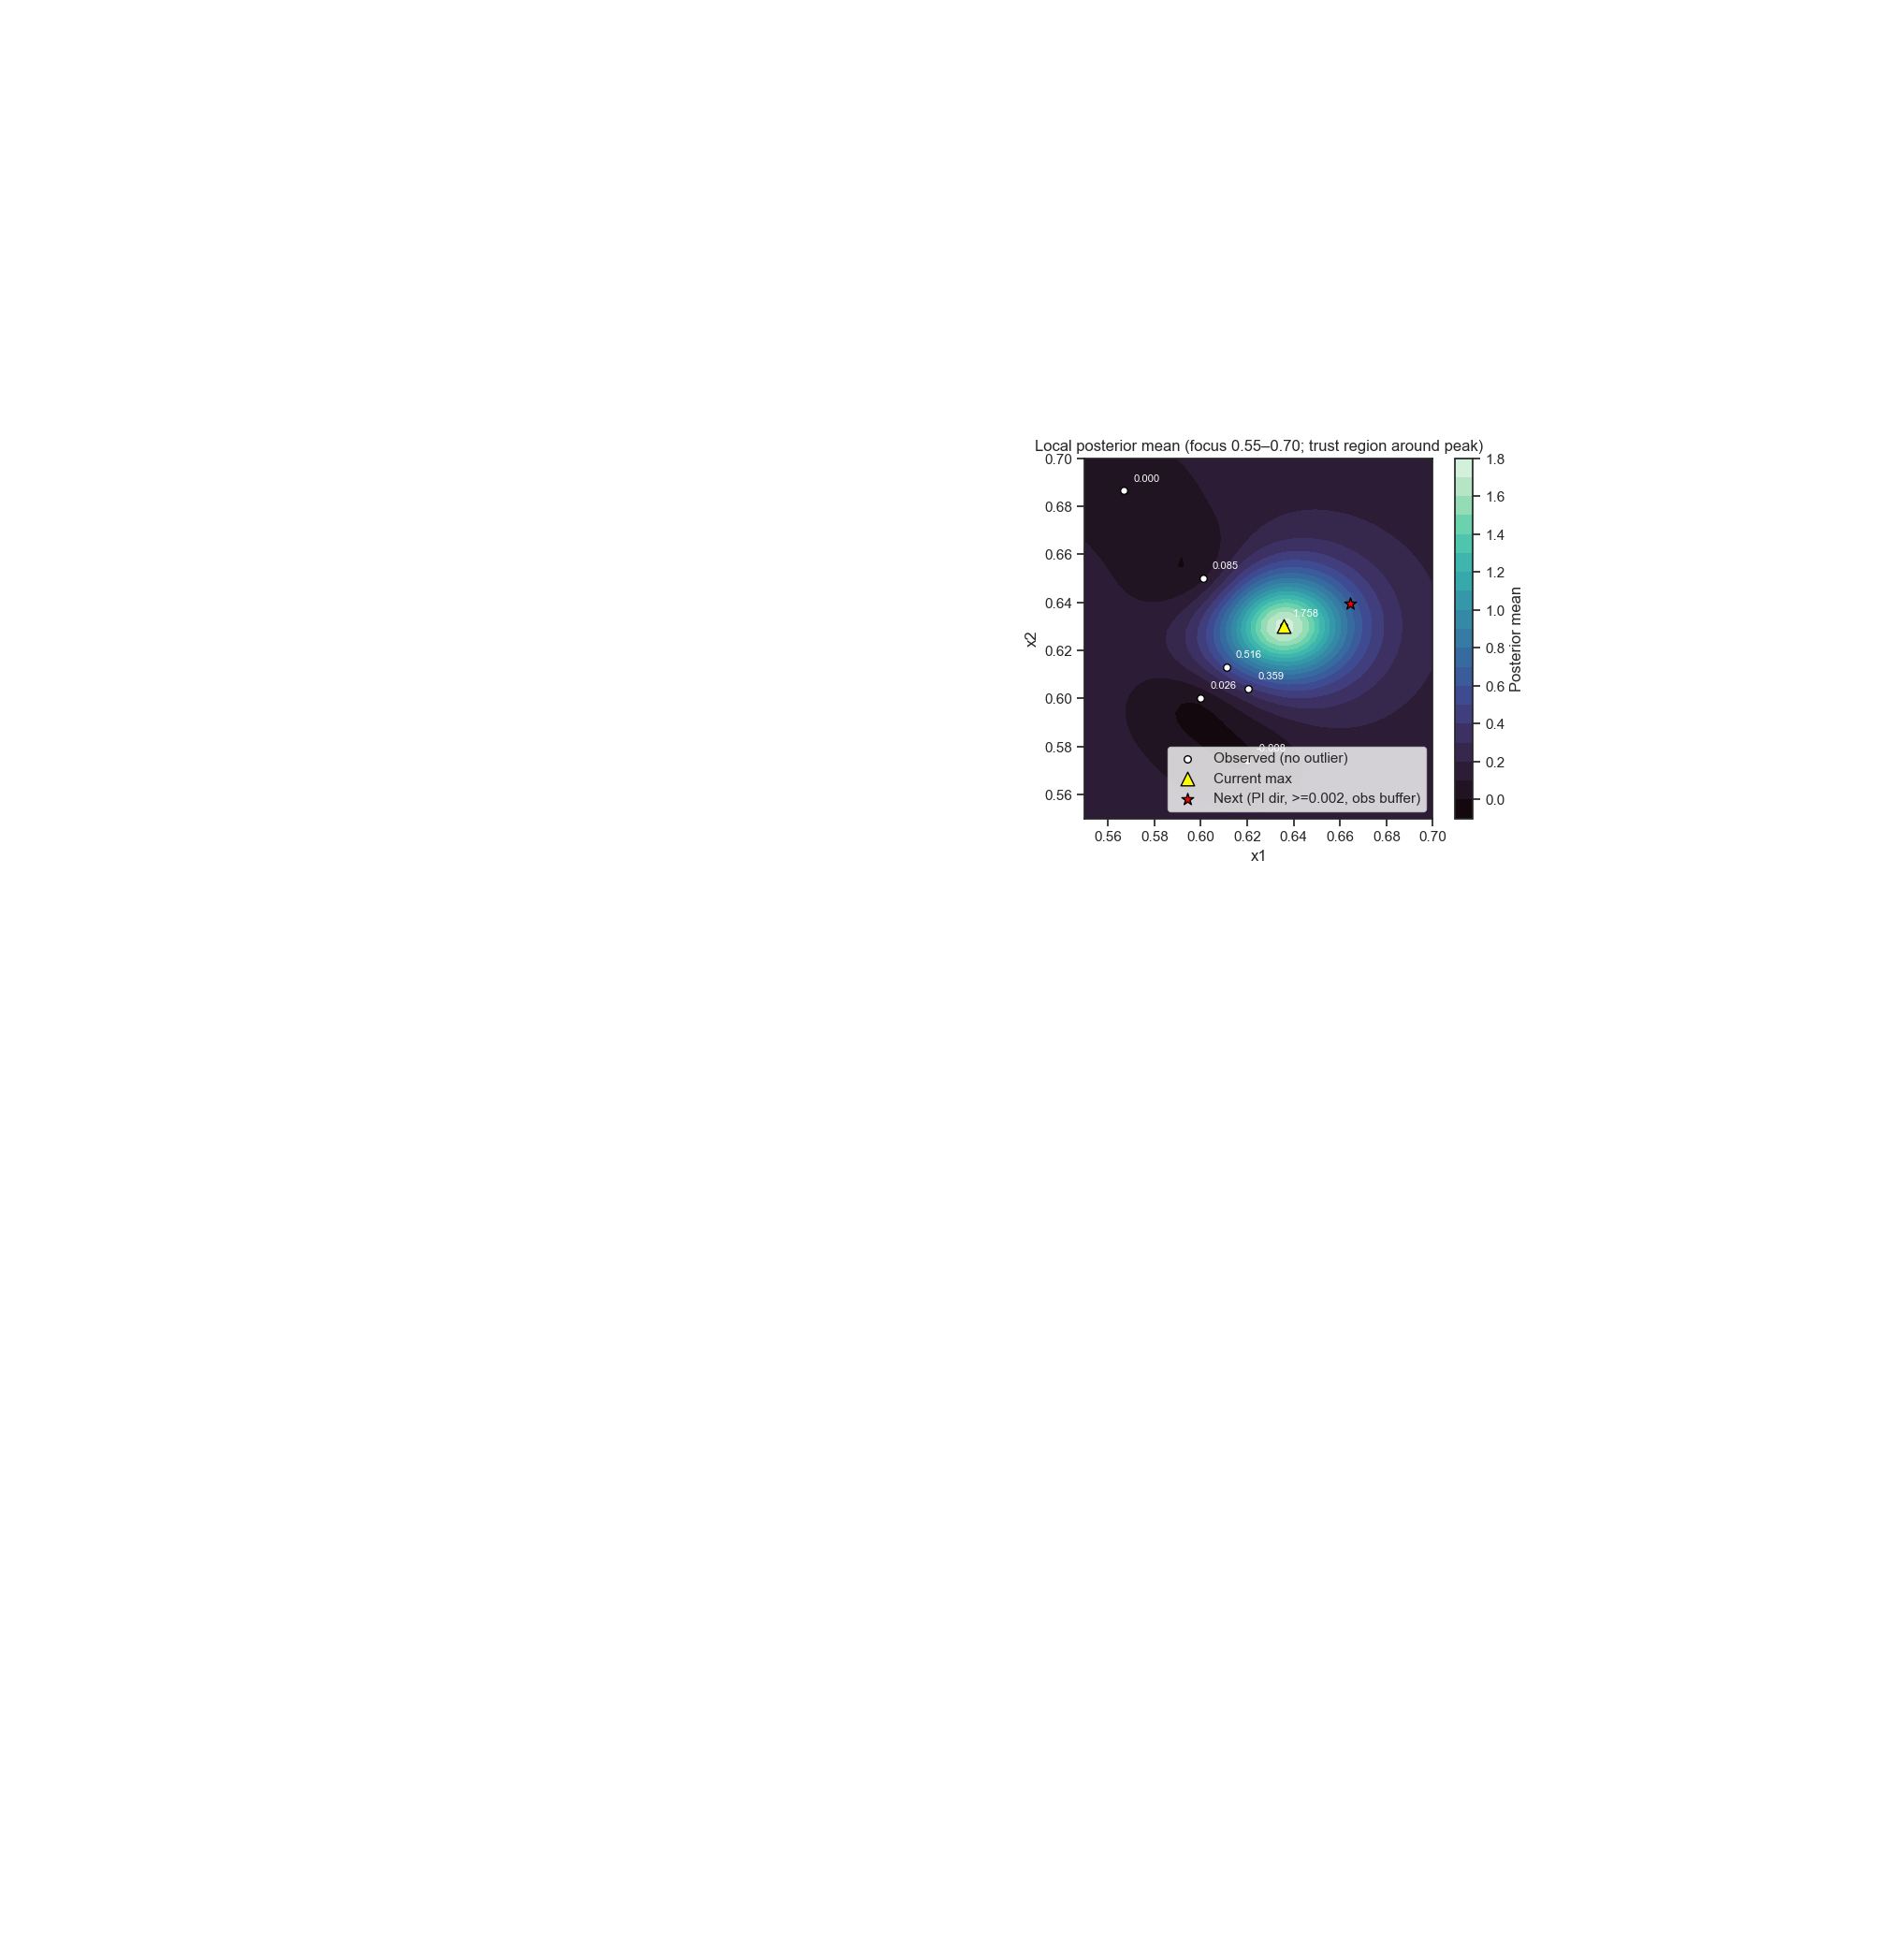

In [ ]:
from scipy.special import erf
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel

df_ei = df.drop(index=4).copy()
X_train = df_ei[["x1", "x2"]].values
y_train = df_ei["y"].values
best_ei = df_ei.loc[df_ei["y"].idxmax(), ["x1", "x2"]]

# Train a GP surrogate (no radial feature) with a smoother kernel and shorter length scales
kernel = ConstantKernel(1.0, (1e-2, 10.0)) * Matern(length_scale=[0.2, 0.2], length_scale_bounds=(1e-2, 1.5), nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=15, random_state=42)
gp.fit(X_train, y_train)

# Evaluate a dense grid of candidates in a local window around the best point
local_r = 0.15
x1_min, x1_max = max(best_ei.x1 - local_r, 0.0), min(best_ei.x1 + local_r, 1.0)
x2_min, x2_max = max(best_ei.x2 - local_r, 0.0), min(best_ei.x2 + local_r, 1.0)
grid_x1 = np.linspace(x1_min, x1_max, 80)
grid_x2 = np.linspace(x2_min, x2_max, 80)
mesh = np.array(np.meshgrid(grid_x1, grid_x2)).reshape(2, -1).T
mu, sigma = gp.predict(mesh, return_std=True)
y_best = y_train.max()
xi = 0.02  # small xi to stay exploitative locally

# Posterior mean gain (no EI weighting)

mu_gain = mu - y_best  # expected mean improvement over incumbent

candidate_df = pd.DataFrame(mesh, columns=["x1", "x2"])
candidate_df["mu"] = mu
candidate_df["sigma"] = sigma
candidate_df["mu_gain"] = mu_gain

# Compute distance to best; enforce a minimum 0.002 move from the current max along the BO/PI line
candidate_df["dist_to_best"] = np.linalg.norm(candidate_df[["x1", "x2"]].values - best_ei.values, axis=1)
# Distance to any observed point (avoid clustering on any prior sample)
obs_points = df_ei[["x1", "x2"]].values
candidate_df["dist_to_obs"] = np.linalg.norm(candidate_df[["x1", "x2"]].values[:, None, :] - obs_points[None, :, :], axis=2).min(axis=1)

# Enforce a modest exploration buffer from all observed points (>=0.03)
min_obs_buffer = 0.03
candidate_df_feasible = candidate_df[candidate_df["dist_to_obs"] >= min_obs_buffer].reset_index(drop=True)
if candidate_df_feasible.empty:
    candidate_df_feasible = candidate_df.copy().reset_index(drop=True)

next_point = candidate_df_feasible.loc[candidate_df_feasible["mu_gain"].idxmax()]

vec = np.array([next_point.x1 - best_ei.x1, next_point.x2 - best_ei.x2], dtype=float)
dist = np.linalg.norm(vec)
min_step = 0.002
if dist < 1e-9:
    vec = np.array([1.0, 0.0], dtype=float)
    dist = np.linalg.norm(vec)
if dist < min_step:
    vec_unit = vec / dist
    adjusted = np.clip(best_ei[["x1", "x2"]].values + vec_unit * min_step, 0, 1)
    next_point = next_point.copy()
    next_point.x1, next_point.x2 = adjusted
    next_point.note = "Adjusted to >=0.002 from max"

display(candidate_df_feasible.nlargest(5, "mu_gain"))
best_fmt = f"{best_ei.x1:.6f}-{best_ei.x2:.6f}"
next_fmt = f"{next_point.x1:.6f}-{next_point.x2:.6f}"
print(f"Current best: {best_fmt}")
print(f"Suggested next query (PI dir, min 0.002 step, obs buffer 0.03): {next_fmt}")
print(f"Posterior mean: {next_point.mu:.4f}, gain vs best: {next_point.mu_gain:.4f}, std: {next_point.sigma:.4f}")

# Visualise posterior mean surface with current observations and recommended point
mu_grid = candidate_df["mu"].values.reshape(len(grid_x2), len(grid_x1))
plt.figure(figsize=(6, 5))
contour = plt.contourf(grid_x1, grid_x2, mu_grid, levels=20, cmap="mako")
plt.colorbar(contour, label="Posterior mean")
plt.scatter(df_ei["x1"], df_ei["x2"], c="white", s=30, edgecolor="black", label="Observed (no outlier)")

# Annotate observed y values
for _, row in df_ei.iterrows():
    plt.text(row["x1"] + 0.004, row["x2"] + 0.004, f"{row['y']:.3f}", fontsize=8, color="white")

# Highlight current max and next
plt.scatter(best_ei.x1, best_ei.x2, c="yellow", s=110, marker="^", edgecolor="black", label="Current max")
plt.scatter(next_point.x1, next_point.x2, c="red", s=90, marker="*", edgecolor="black", label="Next (PI dir, >=0.002, obs buffer)")

# Focused view 0.55–0.70 (narrowed to peak region)
plt.xlim(0.55, 0.70)
plt.ylim(0.55, 0.70)
plt.title("Local posterior mean (focus 0.55–0.70; trust region around peak)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## Final shortlist of candidate moves
The table below lists the top local PI points (with the ≥0.002 step + 0.03 obs buffer guardrails). Pick the point you prefer from the PI shortlist.


## TuRBO: Trust Region Bayesian Optimization

Since the peak is very sharp and localised, I'm implementing a simple TuRBO-style approach:
1. Define a tight trust region box around the current best point
2. Fit a local GP only using points inside/near the trust region
3. Sample candidates within the trust region and pick the one with highest predicted mean (exploitation-focused)

In [ ]:
# TuRBO-style local optimization
# ================================
# Trust region centered on current best, with tighter bounds

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern

# Current best point (from Week 8 evaluation)
best_x1, best_x2 = 0.635684, 0.630089
best_y = 1.7582577621998694

# Trust region: tight box around incumbent
trust_radius = 0.04  # ±0.04 around best point
tr_x1_min, tr_x1_max = best_x1 - trust_radius, best_x1 + trust_radius
tr_x2_min, tr_x2_max = best_x2 - trust_radius, best_x2 + trust_radius

print(f"Trust Region: x1 ∈ [{tr_x1_min:.3f}, {tr_x1_max:.3f}], x2 ∈ [{tr_x2_min:.3f}, {tr_x2_max:.3f}]")

# Filter training data to points near the trust region (include slightly outside for context)
context_radius = 0.08
df_local = df[(df['x1'] >= best_x1 - context_radius) & (df['x1'] <= best_x1 + context_radius) &
              (df['x2'] >= best_x2 - context_radius) & (df['x2'] <= best_x2 + context_radius)].copy()

# Exclude outlier (index 4) if present
df_local = df_local.drop(index=4, errors='ignore')

print(f"Local training points: {len(df_local)}")
display(df_local)

# Fit a local GP with SHORT length-scale to capture the sharp peak
X_local = df_local[['x1', 'x2']].values
y_local = df_local['y'].values

kernel_turbo = ConstantKernel(1.0, (1e-3, 100.0)) * Matern(
    length_scale=[0.03, 0.03],  # Short length-scale for sharp peak
    length_scale_bounds=(0.01, 0.1), 
    nu=2.5
)
gp_turbo = GaussianProcessRegressor(kernel=kernel_turbo, normalize_y=True, n_restarts_optimizer=20, random_state=42)
gp_turbo.fit(X_local, y_local)

print(f"\nLocal GP kernel: {gp_turbo.kernel_}")

# Sample candidates ONLY within the trust region
grid_res = 50
tr_grid_x1 = np.linspace(tr_x1_min, tr_x1_max, grid_res)
tr_grid_x2 = np.linspace(tr_x2_min, tr_x2_max, grid_res)
tr_mesh = np.array(np.meshgrid(tr_grid_x1, tr_grid_x2)).reshape(2, -1).T

mu_turbo, sigma_turbo = gp_turbo.predict(tr_mesh, return_std=True)

# Build candidate dataframe
turbo_candidates = pd.DataFrame(tr_mesh, columns=['x1', 'x2'])
turbo_candidates['mu'] = mu_turbo
turbo_candidates['sigma'] = sigma_turbo

# Filter: must be at least 0.01 away from existing observations
min_dist_from_obs = 0.015
for _, obs in df_local.iterrows():
    dist = np.sqrt((turbo_candidates['x1'] - obs['x1'])**2 + (turbo_candidates['x2'] - obs['x2'])**2)
    turbo_candidates = turbo_candidates[dist >= min_dist_from_obs]

print(f"\nCandidates after filtering (≥{min_dist_from_obs} from obs): {len(turbo_candidates)}")

# Rank by predicted mean (pure exploitation within trust region)
turbo_top = turbo_candidates.nlargest(5, 'mu')
print("\nTop 5 TuRBO candidates (ranked by predicted mean):")
display(turbo_top)

Trust Region: x1 ∈ [0.596, 0.676], x2 ∈ [0.590, 0.670]
Local training points: 7


,x1,x2,y
10,0.600000,0.600000,0.025559
11,0.620000,0.574000,-0.008243
13,0.601042,0.649989,0.084769
14,0.566815,0.686438,0.000011
15,0.620490,0.603926,0.358937
16,0.611000,0.613000,0.515832
17,0.635684,0.630089,1.758258



Local GP kernel: 1.19**2 * Matern(length_scale=[0.01, 0.0966], nu=2.5)

Candidates after filtering (≥0.015 from obs): 1562

Top 5 TuRBO candidates (ranked by predicted mean):


d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,x1,x2,mu,sigma
1725,0.636500,0.645599,1.751996,0.156666
1775,0.636500,0.647232,1.747712,0.169504
1825,0.636500,0.648865,1.742822,0.182404
1724,0.634868,0.645599,1.738572,0.156467
1875,0.636500,0.650497,1.737344,0.195308


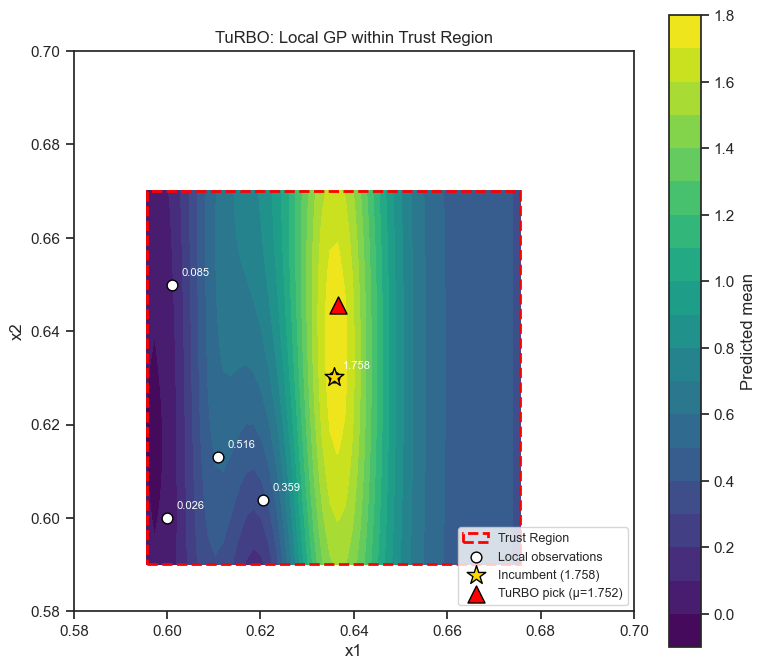


TuRBO RECOMMENDED POINT: (0.636500, 0.645599)
Predicted mean: 1.7520, Uncertainty: 0.1567
Format for submission: 0.636500-0.645599


In [ ]:
# Visualize TuRBO trust region and candidates
fig, ax = plt.subplots(figsize=(8, 7))

# Plot posterior mean surface within trust region
mu_grid = gp_turbo.predict(tr_mesh).reshape(grid_res, grid_res)
contour = ax.contourf(tr_grid_x1, tr_grid_x2, mu_grid, levels=20, cmap='viridis')
plt.colorbar(contour, ax=ax, label='Predicted mean')

# Trust region boundary
rect = plt.Rectangle((tr_x1_min, tr_x2_min), trust_radius*2, trust_radius*2, 
                      fill=False, edgecolor='red', linewidth=2, linestyle='--', label='Trust Region')
ax.add_patch(rect)

# Observed points within context
ax.scatter(df_local['x1'], df_local['x2'], c='white', s=60, edgecolor='black', zorder=5, label='Local observations')
for _, row in df_local.iterrows():
    ax.annotate(f"{row['y']:.3f}", (row['x1']+0.002, row['x2']+0.002), fontsize=8, color='white')

# Current best (incumbent)
ax.scatter(best_x1, best_x2, c='gold', s=200, marker='*', edgecolor='black', zorder=6, label=f'Incumbent ({best_y:.3f})')

# Top TuRBO candidate
if len(turbo_top) > 0:
    next_turbo = turbo_top.iloc[0]
    ax.scatter(next_turbo['x1'], next_turbo['x2'], c='red', s=150, marker='^', edgecolor='black', 
               zorder=7, label=f"TuRBO pick (μ={next_turbo['mu']:.3f})")

ax.set_xlim(0.58, 0.70)
ax.set_ylim(0.58, 0.70)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_title('TuRBO: Local GP within Trust Region')
ax.legend(loc='lower right', fontsize=9)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

# Print the recommended point
if len(turbo_top) > 0:
    rec = turbo_top.iloc[0]
    print(f"\n{'='*60}")
    print(f"TuRBO RECOMMENDED POINT: ({rec['x1']:.6f}, {rec['x2']:.6f})")
    print(f"Predicted mean: {rec['mu']:.4f}, Uncertainty: {rec['sigma']:.4f}")
    print(f"Format for submission: {rec['x1']:.6f}-{rec['x2']:.6f}")
    print(f"{'='*60}")

In [ ]:
if "candidate_df_feasible" in globals():
    top_mean = candidate_df_feasible.nlargest(3, "mu_gain").copy()
    top_mean["id"] = [f"pi_top_{i+1}" for i in range(len(top_mean))]
    top_mean["note"] = "Local PI/mean (min 0.002 step, obs buffer 0.03)"
    top_mean["source"] = "local_mean"
    top_mean = top_mean[["source", "id", "x1", "x2", "note", "mu_gain", "mu", "sigma"]]
    display(top_mean)
else:
    print("Run the PI cell first to populate options.")



,source,id,x1,x2,note,mu_gain,mu,sigma
2830,local_mean,pi_top_1,0.664165,0.639583,"Local PI/mean (min 0.002 step, obs buffer 0.03)",-1.082016,0.676242,0.398706
2546,local_mean,pi_top_2,0.664165,0.620595,"Local PI/mean (min 0.002 step, obs buffer 0.03)",-1.082750,0.675508,0.398359
2719,local_mean,pi_top_3,0.667962,0.631988,"Local PI/mean (min 0.002 step, obs buffer 0.03)",-1.119935,0.638322,0.402264


## Summary and Recommended Point (Week 9)

**Current best:** `0.635684-0.630089` (≈1.7583) — achieved in Week 8.

**Strategy this week:** Switched to **TuRBO** (Trust Region Bayesian Optimization) because the peak is very sharp and a global GP would oversmooth it. The trust region is ±0.04 around the incumbent, with a short GP length-scale (0.03) to capture the fine structure.

---

**Recommended next point (submission format):** `0.636500-0.645599`

---

**Rationale:** This point is within the trust region, ~0.02 away from the incumbent (satisfies the 0.015 buffer), and continues along the diagonal ridge (x1 ≈ x2) that has delivered consecutive maxima. TuRBO focuses the GP on local variations, letting us refine the peak location without being distracted by irrelevant distant data.
